In [1]:
import xarray as xr
from glob import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
files_path = '/home/mduplessis/share/www/data/sg267_WHIRLS_Mission2_2026/*.nc'
files = sorted(glob(files_path))


In [3]:
ds = xr.open_mfdataset(files[-1], decode_timedelta=False)

In [4]:
oxy_time = ds['aa4831_time']
oxy = ds['aa4831_O2']
aanderaa4831_instrument_dissolved_oxygen = ds['aanderaa4831_instrument_dissolved_oxygen']

ctd_time = ds['ctd_time']
ctd_depth = ds['ctd_depth']
ctd_temp = ds['temperature']
ctd_salinity = ds['salinity']

wlbb2fl_sig695nm_adjusted = ds['wlbb2fl_sig695nm_adjusted']
wlbb2fl_results_time = ds['wlbb2fl_results_time']

In [3]:
def interp_depth_to_time(target_time, ctd_time, ctd_depth):
    """Interpolate CTD depth to a target sensor time axis."""
    t_ctd = pd.to_datetime(np.asarray(ctd_time.values)).to_numpy(dtype="datetime64[ns]")
    z_ctd = np.asarray(ctd_depth.values, dtype=float)

    valid_ctd = (~np.isnat(t_ctd)) & np.isfinite(z_ctd)
    t_ctd = t_ctd[valid_ctd]
    z_ctd = z_ctd[valid_ctd]

    order = np.argsort(t_ctd)
    t_ctd_num = t_ctd[order].astype("int64").astype(float)
    z_ctd = z_ctd[order]

    t_target = pd.to_datetime(np.asarray(target_time.values)).to_numpy(dtype="datetime64[ns]")
    z_target = np.full(t_target.shape, np.nan, dtype=float)

    valid_target = ~np.isnat(t_target)
    t_target_num = t_target[valid_target].astype("int64").astype(float)

    in_range = (t_target_num >= t_ctd_num[0]) & (t_target_num <= t_ctd_num[-1])
    z_interp = np.full(t_target_num.shape, np.nan, dtype=float)
    z_interp[in_range] = np.interp(t_target_num[in_range], t_ctd_num, z_ctd)
    z_target[valid_target] = z_interp

    return z_target

In [6]:
# Interpolate depth for oxygen and chlorophyll sensor timestamps
oxy_depth = interp_depth_to_time(oxy_time, ctd_time, ctd_depth)
chl_depth = interp_depth_to_time(wlbb2fl_results_time, ctd_time, ctd_depth)

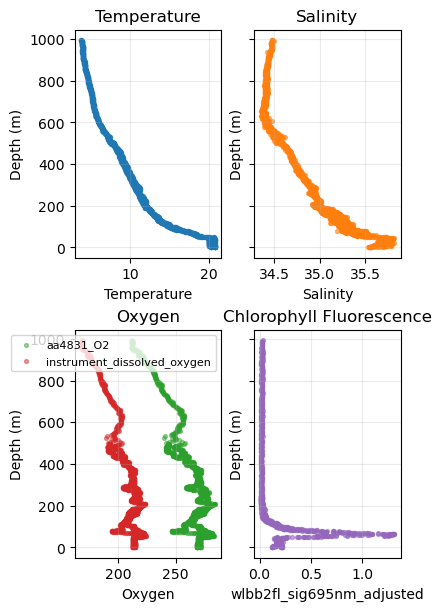

In [7]:
# Convert data arrays to numpy for plotting
temp = np.asarray(ctd_temp.values, dtype=float)
sal = np.asarray(ctd_salinity.values, dtype=float)
ctd_z = np.asarray(ctd_depth.values, dtype=float)
oxy_raw = np.asarray(oxy.values, dtype=float)
oxy_corr = np.asarray(aanderaa4831_instrument_dissolved_oxygen.values, dtype=float)
chl = np.asarray(wlbb2fl_sig695nm_adjusted.values, dtype=float)

fig, axes = plt.subplots(2, 2, figsize=(4, 6), sharey=True, constrained_layout=True)
ax1, ax2, ax3, ax4 = axes.ravel()

m = np.isfinite(temp) & np.isfinite(ctd_z)
ax1.scatter(temp[m], ctd_z[m], s=8, alpha=0.55)
ax1.set_title("Temperature")
ax1.set_xlabel("Temperature")
ax1.set_ylabel("Depth (m)")
ax1.grid(alpha=0.25)

m = np.isfinite(sal) & np.isfinite(ctd_z)
ax2.scatter(sal[m], ctd_z[m], s=8, alpha=0.55, color="tab:orange")
ax2.set_title("Salinity")
ax2.set_xlabel("Salinity")
ax2.set_ylabel("Depth (m)")
ax2.grid(alpha=0.25)

m_raw = np.isfinite(oxy_raw) & np.isfinite(oxy_depth)
m_corr = np.isfinite(oxy_corr) & np.isfinite(oxy_depth)
ax3.scatter(oxy_raw[m_raw], oxy_depth[m_raw], s=8, alpha=0.45, label="aa4831_O2", color="tab:green")
ax3.scatter(
    oxy_corr[m_corr],
    oxy_depth[m_corr],
    s=8,
    alpha=0.45,
    label="instrument_dissolved_oxygen",
    color="tab:red",
)
ax3.set_title("Oxygen")
ax3.set_xlabel("Oxygen")
ax3.set_ylabel("Depth (m)")
ax3.grid(alpha=0.25)
ax3.legend(loc="best", fontsize=8)

m = np.isfinite(chl) & np.isfinite(chl_depth)
ax4.scatter(chl[m], chl_depth[m], s=8, alpha=0.55, color="tab:purple")
ax4.set_title("Chlorophyll Fluorescence")
ax4.set_xlabel("wlbb2fl_sig695nm_adjusted")
ax4.set_ylabel("Depth (m)")
ax4.grid(alpha=0.25)

for ax in (ax1, ax2, ax3, ax4):
    ax.invert_yaxis()

plt.show()

In [4]:
# Build profile-by-profile 2D grids (time x depth) from all mission files
if len(files) == 0:
    raise ValueError("No NetCDF files found. Check files_path.")


def _to_datetime64_ns(values):
    return pd.to_datetime(np.asarray(values)).to_numpy(dtype="datetime64[ns]")


def _interp_profile_to_depth(var_values, depth_values, depth_grid):
    valid = np.isfinite(var_values) & np.isfinite(depth_values)
    if np.count_nonzero(valid) < 2:
        return np.full(depth_grid.shape, np.nan, dtype=float)

    d = depth_values[valid]
    v = var_values[valid]
    order = np.argsort(d)
    d = d[order]
    v = v[order]

    d_unique, inv = np.unique(d, return_inverse=True)
    if d_unique.size < 2:
        return np.full(depth_grid.shape, np.nan, dtype=float)

    v_sum = np.zeros(d_unique.size, dtype=float)
    v_count = np.zeros(d_unique.size, dtype=float)
    np.add.at(v_sum, inv, v)
    np.add.at(v_count, inv, 1.0)
    v_unique = v_sum / v_count

    out = np.full(depth_grid.shape, np.nan, dtype=float)
    in_range = (depth_grid >= d_unique[0]) & (depth_grid <= d_unique[-1])
    out[in_range] = np.interp(depth_grid[in_range], d_unique, v_unique)
    return out

In [ ]:
# Build profile-by-profile 2D grids (time x depth) from all mission files
if len(files) == 0:
    raise ValueError("No NetCDF files found. Check files_path.")


def _to_datetime64_ns(values):
    return pd.to_datetime(np.asarray(values)).to_numpy(dtype="datetime64[ns]")


def _interp_profile_to_depth(var_values, depth_values, depth_grid):
    valid = np.isfinite(var_values) & np.isfinite(depth_values)
    if np.count_nonzero(valid) < 2:
        return np.full(depth_grid.shape, np.nan, dtype=float)

    d = depth_values[valid]
    v = var_values[valid]
    order = np.argsort(d)
    d = d[order]
    v = v[order]

    d_unique, inv = np.unique(d, return_inverse=True)
    if d_unique.size < 2:
        return np.full(depth_grid.shape, np.nan, dtype=float)

    v_sum = np.zeros(d_unique.size, dtype=float)
    v_count = np.zeros(d_unique.size, dtype=float)
    np.add.at(v_sum, inv, v)
    np.add.at(v_count, inv, 1.0)
    v_unique = v_sum / v_count

    out = np.full(depth_grid.shape, np.nan, dtype=float)
    in_range = (depth_grid >= d_unique[0]) & (depth_grid <= d_unique[-1])
    out[in_range] = np.interp(depth_grid[in_range], d_unique, v_unique)
    return out


raw_profiles = []
max_depth = 0.0

for file_path in files:
    with xr.open_dataset(file_path, decode_timedelta=False) as dsi:
        # Need CTD time/depth to define profiles; individual variables are optional per file.
        required_ctd = {"ctd_time", "ctd_depth"}
        if not required_ctd.issubset(set(dsi.variables)):
            continue

        t_ctd = _to_datetime64_ns(dsi["ctd_time"].values)
        z_ctd = np.asarray(dsi["ctd_depth"].values, dtype=float)

        valid_ctd = (~np.isnat(t_ctd)) & np.isfinite(z_ctd)
        valid_idx = np.where(valid_ctd)[0]
        if valid_idx.size < 3:
            continue

        z_valid = z_ctd[valid_ctd]
        local_peak = int(np.nanargmax(z_valid))
        peak_idx = int(valid_idx[local_peak])
        max_depth = max(max_depth, float(np.nanmax(z_valid)))

        idx_all = np.arange(z_ctd.size)
        cast_masks = {
            "downcast": valid_ctd & (idx_all <= peak_idx),
            "upcast": valid_ctd & (idx_all >= peak_idx),
        }

        # Optional variables per file.
        if "temperature" in dsi.variables:
            temp_full = np.asarray(dsi["temperature"].values, dtype=float)
        else:
            temp_full = np.full(z_ctd.shape, np.nan, dtype=float)

        if "salinity" in dsi.variables:
            sal_full = np.asarray(dsi["salinity"].values, dtype=float)
        else:
            sal_full = np.full(z_ctd.shape, np.nan, dtype=float)

        has_oxy = {"aa4831_time", "aa4831_O2", "aanderaa4831_instrument_dissolved_oxygen"}.issubset(
            set(dsi.variables)
        )
        if has_oxy:
            oxy_time_full = _to_datetime64_ns(dsi["aa4831_time"].values)
            oxy_depth_full = interp_depth_to_time(dsi["aa4831_time"], dsi["ctd_time"], dsi["ctd_depth"])
            oxy_raw_full = np.asarray(dsi["aa4831_O2"].values, dtype=float)
            oxy_corr_full = np.asarray(dsi["aanderaa4831_instrument_dissolved_oxygen"].values, dtype=float)
        else:
            oxy_time_full = np.array([], dtype="datetime64[ns]")
            oxy_depth_full = np.array([], dtype=float)
            oxy_raw_full = np.array([], dtype=float)
            oxy_corr_full = np.array([], dtype=float)

        has_chl = {"wlbb2fl_results_time", "wlbb2fl_sig695nm_adjusted"}.issubset(set(dsi.variables))
        if has_chl:
            chl_time_full = _to_datetime64_ns(dsi["wlbb2fl_results_time"].values)
            chl_depth_full = interp_depth_to_time(dsi["wlbb2fl_results_time"], dsi["ctd_time"], dsi["ctd_depth"])
            chl_full = np.asarray(dsi["wlbb2fl_sig695nm_adjusted"].values, dtype=float)
        else:
            chl_time_full = np.array([], dtype="datetime64[ns]")
            chl_depth_full = np.array([], dtype=float)
            chl_full = np.array([], dtype=float)

        for cast_type, cast_mask in cast_masks.items():
            if np.count_nonzero(cast_mask) < 3:
                continue

            t_cast = t_ctd[cast_mask]
            z_cast = z_ctd[cast_mask]

            t0 = t_cast.min()
            t1 = t_cast.max()
            t_mid = t0 + (t1 - t0) / np.int64(2)

            oxy_mask = (
                (~np.isnat(oxy_time_full))
                & (oxy_time_full >= t0)
                & (oxy_time_full <= t1)
                & np.isfinite(oxy_depth_full)
            )
            chl_mask = (
                (~np.isnat(chl_time_full))
                & (chl_time_full >= t0)
                & (chl_time_full <= t1)
                & np.isfinite(chl_depth_full)
            )

            raw_profiles.append(
                {
                    "time_mid": t_mid,
                    "cast_type": cast_type,
                    "source_file": file_path.split("/")[-1],
                    "ctd_depth": z_cast,
                    "temperature": temp_full[cast_mask],
                    "salinity": sal_full[cast_mask],
                    "oxy_depth": oxy_depth_full[oxy_mask],
                    "oxy_raw": oxy_raw_full[oxy_mask],
                    "oxy_corr": oxy_corr_full[oxy_mask],
                    "chl_depth": chl_depth_full[chl_mask],
                    "chlorophyll": chl_full[chl_mask],
                }
            )

if len(raw_profiles) == 0:
    raise ValueError("No valid down/upcast profiles were found.")

if not np.isfinite(max_depth) or max_depth <= 0:
    raise ValueError("Could not determine a valid maximum depth.")

depth_grid = np.arange(0.0, np.floor(max_depth) + 1.0, 1.0)

gridded = []
for rec in raw_profiles:
    gridded.append(
        {
            "time_mid": rec["time_mid"],
            "cast_type": rec["cast_type"],
            "source_file": rec["source_file"],
            "temperature": _interp_profile_to_depth(rec["temperature"], rec["ctd_depth"], depth_grid),
            "salinity": _interp_profile_to_depth(rec["salinity"], rec["ctd_depth"], depth_grid),
            "oxygen_raw": _interp_profile_to_depth(rec["oxy_raw"], rec["oxy_depth"], depth_grid),
            "oxygen_corrected": _interp_profile_to_depth(rec["oxy_corr"], rec["oxy_depth"], depth_grid),
            "chlorophyll": _interp_profile_to_depth(rec["chlorophyll"], rec["chl_depth"], depth_grid),
        }
    )

time_vals = np.array([g["time_mid"] for g in gridded], dtype="datetime64[ns]")
order = np.argsort(time_vals)

stack = lambda key: np.vstack([gridded[i][key] for i in order])

cast_type_vals = np.array([gridded[i]["cast_type"] for i in order], dtype=object)
source_file_vals = np.array([gridded[i]["source_file"] for i in order], dtype=object)

ds_sections = xr.Dataset(
    data_vars={
        "temperature": (("time", "depth"), stack("temperature")),
        "salinity": (("time", "depth"), stack("salinity")),
        "oxygen_raw": (("time", "depth"), stack("oxygen_raw")),
        "oxygen_corrected": (("time", "depth"), stack("oxygen_corrected")),
        "chlorophyll": (("time", "depth"), stack("chlorophyll")),
    },
    coords={
        "time": time_vals[order],
        "depth": depth_grid,
        "cast_type": ("time", cast_type_vals),
        "source_file": ("time", source_file_vals),
    },
)

print(ds_sections)
print(f"Profiles gridded: {ds_sections.sizes['time']}, Depth levels: {ds_sections.sizes['depth']}")

In [15]:
import cmocean.cm as cmo

In [1]:
# Compute potential density (sigma-0) from T/S for contour overlays
import gsw
from scipy.ndimage import gaussian_filter

sal_grid = ds_sections["salinity"].values      # (time, depth)
temp_grid = ds_sections["temperature"].values  # (time, depth)

# Approximate absolute salinity and conservative temperature (pressure=0, typical Southern Ocean lat)
SA = gsw.SA_from_SP(sal_grid, 0, 0, -55)
CT = gsw.CT_from_t(SA, temp_grid, 0)
sigma0 = gsw.sigma0(SA, CT)  # shape (time, depth)

# sigma0 transposed to (depth, time) for contour/pcolormesh orientation
sigma0_plot = sigma0.T

# Smooth density field for cleaner contours; NaNs filled with nearest valid value first
sigma0_filled = sigma0_plot.copy()
mask = ~np.isfinite(sigma0_filled)
# Simple fill: replace NaNs with the column mean so smoothing doesn't smear NaN boundaries
col_means = np.nanmean(sigma0_filled, axis=0, keepdims=True)
sigma0_filled = np.where(mask, np.broadcast_to(col_means, sigma0_filled.shape), sigma0_filled)
sigma0_smooth = gaussian_filter(sigma0_filled, sigma=2)
# Restore NaN mask after smoothing
sigma0_smooth[mask] = np.nan

# Choose contour levels based on data range, ignoring NaN
sigma0_finite = sigma0_smooth[np.isfinite(sigma0_smooth)]
if sigma0_finite.size > 0:
    dens_levels = np.arange(
        np.floor(sigma0_finite.min() * 2) / 2,
        np.ceil(sigma0_finite.max() * 2) / 2 + 0.3,
        0.3,
    )
else:
    dens_levels = None

# Plot pcolormesh sections (time x depth) as stacked panels
fig, axes = plt.subplots(4, 1, figsize=(8, 8), sharex=True, sharey=True, constrained_layout=True)

plot_specs = [
    ("temperature", "Temperature", cmo.thermal, 0, 30),
    ("salinity", "Salinity", cmo.haline, 34, 36),
    ("oxygen_corrected", "Oxygen (corrected)", cmo.oxy, 140, 230),
    ("chlorophyll", "Chlorophyll", cmo.algae, 0, 3),
]

time_coords = ds_sections["time"].values
depth_coords = ds_sections["depth"].values

for ax, (var_name, title, cmap, vmin, vmax) in zip(axes, plot_specs):
    C = ds_sections[var_name].transpose("depth", "time").values
    pcm = ax.pcolormesh(
        time_coords,
        depth_coords,
        C,
        shading="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(title)
    ax.set_ylabel("Depth (m)")
    ax.grid(alpha=0.2)
    ax.invert_yaxis()
    cbar = fig.colorbar(pcm, ax=ax, pad=0.02)
    cbar.set_label(title)

    # Smoothed density contours
    if dens_levels is not None:
        cs = ax.contour(
            time_coords,
            depth_coords,
            sigma0_smooth,
            levels=dens_levels,
            colors="k",
            linewidths=0.7,
            alpha=0.6,
        )
        ax.clabel(cs, fmt="%.2f", fontsize=7, inline=True)

for ax in axes:
    ax.tick_params(axis="x", rotation=30)
    ax.set_ylim(1000, 0)

axes[-1].set_xlabel("Profile midpoint time")

plt.show()

ModuleNotFoundError: No module named 'scipy'